In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
details = pd.read_csv("Details.csv")
orders = pd.read_csv("Orders.csv")

In [ ]:
print("Orders:", orders.shape)
print("Details:", details.shape)

print(orders.head())
print(details.head())

Orders: (500, 5)
Details: (1500, 7)
  Order ID  Order Date CustomerName           State     City
0  B-26055  10-03-2018    Harivansh   Uttar Pradesh  Mathura
1  B-25993  03-02-2018       Madhav           Delhi    Delhi
2  B-25973  24-01-2018  Madan Mohan   Uttar Pradesh  Mathura
3  B-25923  27-12-2018        Gopal     Maharashtra   Mumbai
4  B-25757  21-08-2018     Vishakha  Madhya Pradesh   Indore
  Order ID  Amount  Profit  Quantity     Category      Sub-Category  \
0  B-25681    1096     658         7  Electronics  Electronic Games   
1  B-26055    5729      64        14    Furniture            Chairs   
2  B-25955    2927     146         8    Furniture         Bookcases   
3  B-26093    2847     712         8  Electronics          Printers   
4  B-25602    2617    1151         4  Electronics            Phones   

   PaymentMode  
0          COD  
1          EMI  
2          EMI  
3  Credit Card  
4  Credit Card  


In [ ]:
print(orders.info())
print(details.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
dtypes: int64(3), object(4)
memory usage: 82.2+ KB
None


In [ ]:
print("Orders missing values:")
print(orders.isnull().sum())

print("\nDetails missing values:")
print(details.isnull().sum())

Orders missing values:
Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

Details missing values:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64


In [ ]:
data = orders.merge(
    details,
    on="Order ID",
    how="inner"
)

print(data.shape)
print(data.head())

(1500, 11)
  Order ID  Order Date CustomerName          State     City  Amount  Profit  \
0  B-26055  10-03-2018    Harivansh  Uttar Pradesh  Mathura    5729      64   
1  B-26055  10-03-2018    Harivansh  Uttar Pradesh  Mathura     671     114   
2  B-26055  10-03-2018    Harivansh  Uttar Pradesh  Mathura     443      11   
3  B-26055  10-03-2018    Harivansh  Uttar Pradesh  Mathura      57       7   
4  B-26055  10-03-2018    Harivansh  Uttar Pradesh  Mathura     227      48   

   Quantity     Category Sub-Category  PaymentMode  
0        14    Furniture       Chairs          EMI  
1         9  Electronics       Phones  Credit Card  
2         1     Clothing        Saree          COD  
3         2     Clothing        Shirt          UPI  
4         5     Clothing        Stole          COD  


In [ ]:
# 1. Profit distribution
# How is profit distributed across transactions, and is profitability concentrated in a small number of transactions?

order_profit = (
    details.groupby("Order ID", as_index=False)
           .agg(
               total_sales=("Amount", "sum"),
               total_profit=("Profit", "sum")
           )
)
# BASIC DISTRIBUTION

print("Mean Profit:", round(order_profit["total_profit"].mean(), 2))
print("Median Profit:", round(order_profit["total_profit"].median(), 2))
print("Standard Deviation:", round(order_profit["total_profit"].std(), 2))
print("Minimum Profit:", round(order_profit["total_profit"].min(), 2))
print("Maximum Profit:", round(order_profit["total_profit"].max(), 2))

# PROFIT CONCENTRATION
positive_orders = order_profit[
    order_profit["total_profit"] > 0
].copy()

positive_orders = positive_orders.sort_values(
    "total_profit",
    ascending=False
)

top_10_count = int(np.ceil(len(positive_orders) * 0.10))

top_10_profit = positive_orders.head(
    top_10_count
)["total_profit"].sum()

total_positive_profit = positive_orders[
    "total_profit"
].sum()

profit_concentration = (
    top_10_profit / total_positive_profit
) * 100

print(
    "Top 10% profitable orders contribute:",
    round(profit_concentration, 2),
    "% of total positive profit"
)


Mean Profit: 73.93
Median Profit: 22.0
Standard Deviation: 313.09
Minimum Profit: -1836
Maximum Profit: 2272
Top 10% profitable orders contribute: 46.34 % of total positive profit


Sales-Profit Correlation: 0.33


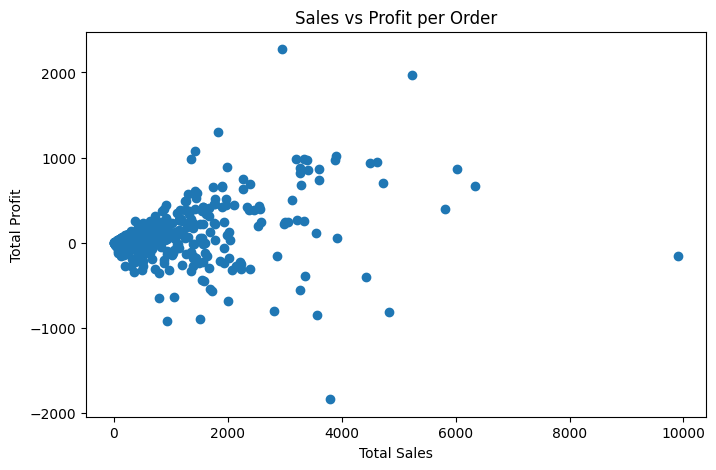

In [ ]:
# 2. Sales–profit relationship
# How strongly are sales and profit related, and do higher-value transactions consistently generate higher profit?


sales_profit_corr = order_profit[
    "total_sales"
].corr(
    order_profit["total_profit"]
)

print(
    "Sales-Profit Correlation:",
    round(sales_profit_corr, 2)
)

# VISUALIZATION

plt.figure(figsize=(8, 5))

plt.scatter(
    order_profit["total_sales"],
    order_profit["total_profit"]
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.title("Sales vs Profit per Order")

plt.show()

Quantity-Profit Correlation: 0.2


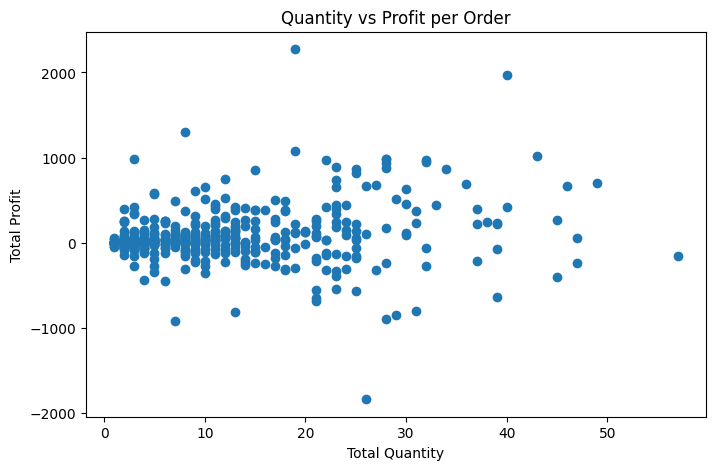

In [ ]:
# 3. Quantity–profit relationship
# Does selling higher quantities translate into proportionally higher profit?

order_quantity = (
    details.groupby("Order ID", as_index=False)
           .agg(
               total_quantity=("Quantity", "sum"),
               total_profit=("Profit", "sum")
           )
)
quantity_profit_corr = order_quantity[
    "total_quantity"
].corr(
    order_quantity["total_profit"]
)

print(
    "Quantity-Profit Correlation:",
    round(quantity_profit_corr, 2)
)
# VISUALIZATION
plt.figure(figsize=(8, 5))

plt.scatter(
    order_quantity["total_quantity"],
    order_quantity["total_profit"]
)

plt.xlabel("Total Quantity")
plt.ylabel("Total Profit")
plt.title("Quantity vs Profit per Order")

plt.show()

In [30]:
# 4. Outlier detection
# Are there unusually high- or low-value sales/profit transactions that could distort the overall profitability picture?

Q1_sales = order_profit["total_sales"].quantile(0.25)
Q3_sales = order_profit["total_sales"].quantile(0.75)

IQR_sales = Q3_sales - Q1_sales

lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

sales_outliers = order_profit[
    (order_profit["total_sales"] < lower_sales) |
    (order_profit["total_sales"] > upper_sales)
]

print("Sales outliers:", len(sales_outliers))
print(
    sales_outliers.sort_values(
        "total_sales",
        ascending=False
    ).head(10)
)
# PROFIT OUTLIERS

Q1_profit = order_profit["total_profit"].quantile(0.25)
Q3_profit = order_profit["total_profit"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = order_profit[
    (order_profit["total_profit"] < lower_profit) |
    (order_profit["total_profit"] > upper_profit)
]

print("Profit outliers:", len(profit_outliers))

print("Highest Profit Outliers:")
print(
    profit_outliers
    .sort_values("total_profit", ascending=False)
    .head(10)
)

print("Lowest Profit Outliers:")
print(
    profit_outliers
    .sort_values("total_profit", ascending=True)
    .head(10)
)

Sales outliers: 33
    Order ID  total_sales  total_profit
454  B-26055         9902          -157
354  B-25955         6339           669
392  B-25993         6026           864
280  B-25881         5809           400
372  B-25973         5228          1970
322  B-25923         4836          -816
450  B-26051         4719           702
254  B-25855         4613           948
492  B-26093         4502           938
52   B-25653         4434          -406
Profit outliers: 94
Highest Profit Outliers:
    Order ID  total_sales  total_profit
7    B-25608         2953          2272
372  B-25973         5228          1970
421  B-26022         1824          1303
0    B-25601         1429          1078
55   B-25656         3895          1021
154  B-25755         3204           984
160  B-25761         3339           984
178  B-25779         1361           980
1    B-25602         3889           975
252  B-25853         3388           970
Lowest Profit Outliers:
    Order ID  total_sales  total

In [ ]:
# 5. Customer profitability patterns
# What patterns distinguish high-value/high-profit customers from customers generating high sales but comparatively lower profit?

# CUSTOMER LEVEL METRICS
customer_analysis = (
    data.groupby("CustomerName")
        .agg(
            total_sales=("Amount", "sum"),
            total_profit=("Profit", "sum"),
            total_quantity=("Quantity", "sum"),
            total_orders=("Order ID", "nunique")
        )
        .reset_index()
)

# PROFIT MARGIN
customer_analysis["profit_margin"] = (
    customer_analysis["total_profit"] /
    customer_analysis["total_sales"] * 100
)

# HIGH-SALES BUT LOW MARGIN CUSTOMERS

high_sales_customers = customer_analysis[
    customer_analysis["total_sales"] >=
    customer_analysis["total_sales"].median()
]

high_sales_low_margin = high_sales_customers[
    high_sales_customers["profit_margin"] <
    customer_analysis["profit_margin"].median()
]

print(
    high_sales_low_margin.sort_values(
        "total_sales",
        ascending=False
    )
)

# HIGH-SALES + HIGH-PROFIT CUSTOMERS

high_sales_high_profit = customer_analysis[
    (customer_analysis["total_sales"] >=
     customer_analysis["total_sales"].median())
    &
    (customer_analysis["total_profit"] >=
     customer_analysis["total_profit"].median())
]

print("High Sales + High Profit Customers:")

print(
    high_sales_high_profit
    .sort_values("total_profit", ascending=False)
    .head(10)
)

    CustomerName  total_sales  total_profit  total_quantity  total_orders  \
102    Harivansh         9902          -157              57             1   
328     Vishakha         6120          -173              59             2   
139       Lalita         5809           400              23             1   
269       Shruti         5750           485              67             4   
7       Abhishek         5597           484              75             4   
..           ...          ...           ...             ...           ...   
241       Sanjna          826           -48              15             1   
304        Sweta          808           -56              17             2   
13       Akancha          806            22              10             1   
333         Yash          789          -647              21             1   
72       Charika          768            -4               8             1   

     profit_margin  
102      -1.585538  
328      -2.826797  
139       6.

In [29]:
# 6. Profit concentration
# How concentrated is ZyvanaCart's total profit among customers,
# categories, and sub-categories?

# --------------------------------------------------
# CUSTOMER PROFIT CONCENTRATION
# --------------------------------------------------

customer_profit = (
    data.groupby("CustomerName", as_index=False)
        .agg(total_profit=("Profit", "sum"))
)

customer_positive = customer_profit[
    customer_profit["total_profit"] > 0
].sort_values(
    "total_profit",
    ascending=False
)

top_customer_count = int(
    np.ceil(len(customer_positive) * 0.10)
)

top_customer_profit = (
    customer_positive
    .head(top_customer_count)["total_profit"]
    .sum()
)

total_positive_customer_profit = (
    customer_positive["total_profit"].sum()
)

customer_contribution = (
    top_customer_profit /
    total_positive_customer_profit
) * 100

print(
    "Top 10% customers contribute:",
    round(customer_contribution, 2),
    "% of total positive profit"
)


# --------------------------------------------------
# CATEGORY PROFIT CONTRIBUTION
# --------------------------------------------------

category_profit = (
    details.groupby("Category", as_index=False)
           .agg(total_profit=("Profit", "sum"))
)

category_positive = category_profit[
    category_profit["total_profit"] > 0
].sort_values(
    "total_profit",
    ascending=False
)

category_positive["profit_contribution"] = (
    category_positive["total_profit"] /
    category_positive["total_profit"].sum()
) * 100

print("\nCategory Profit Contribution:")

print(
    category_positive.round(2)
)


# --------------------------------------------------
# SUB-CATEGORY PROFIT CONCENTRATION
# --------------------------------------------------

subcategory_profit = (
    details.groupby("Sub-Category", as_index=False)
           .agg(total_profit=("Profit", "sum"))
)

subcategory_positive = subcategory_profit[
    subcategory_profit["total_profit"] > 0
].sort_values(
    "total_profit",
    ascending=False
)

top_subcategory_count = int(
    np.ceil(len(subcategory_positive) * 0.10)
)

top_subcategory_profit = (
    subcategory_positive
    .head(top_subcategory_count)["total_profit"]
    .sum()
)

total_positive_subcategory_profit = (
    subcategory_positive["total_profit"].sum()
)

subcategory_contribution = (
    top_subcategory_profit /
    total_positive_subcategory_profit
) * 100

print(
    "\nTop 10% sub-categories contribute:",
    round(subcategory_contribution, 2),
    "% of total positive profit"
)




Top 10% customers contribute: 42.61 % of total positive profit

Category Profit Contribution:
      Category  total_profit  profit_contribution
0     Clothing         13325                36.05
1  Electronics         13162                35.61
2    Furniture         10476                28.34

Top 10% sub-categories contribute: 38.52 % of total positive profit


In [ ]:
# 7. Category profitability behavior
# How does profitability vary within each category rather than only comparing category totals?

category_customer = (
    data.groupby(
        ["Category", "CustomerName"]
    )
    .agg(
        total_sales=("Amount", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)
category_customer["profit_margin"] = (
    category_customer["total_profit"] /
    category_customer["total_sales"] * 100
)

# SUMMERIZING THE VARIATION

category_summary = (
    category_customer
    .groupby("Category")
    .agg(
        average_profit=("total_profit", "mean"),
        median_profit=("total_profit", "median"),
        profit_std=("total_profit", "std"),
        average_margin=("profit_margin", "mean"),
        lowest_profit=("total_profit", "min"),
        highest_profit=("total_profit", "max")
    )
    .reset_index()
)

print(category_summary.round(2))

      Category  average_profit  median_profit  profit_std  average_margin  \
0     Clothing           47.59           26.0      150.85            6.65   
1  Electronics           79.29           37.5      340.04            1.14   
2    Furniture           65.47           21.5      319.48           -1.64   

   lowest_profit  highest_profit  
0           -456             887  
1           -916            1698  
2          -1981            1633  


In [ ]:
# 8. Low-margin high-sales investigation
# What characteristics are common among segments generating substantial sales but relatively weak profit margins?

subcategory_analysis = (
    details.groupby("Sub-Category")
           .agg(
               total_sales=("Amount", "sum"),
               total_profit=("Profit", "sum"),
               total_quantity=("Quantity", "sum")
           )
           .reset_index()
)
subcategory_analysis["profit_margin"] = (
    subcategory_analysis["total_profit"] /
    subcategory_analysis["total_sales"] * 100
)

# Identifying high-sales + low-margin segments:

high_sales_low_margin = subcategory_analysis[
    (subcategory_analysis["total_sales"] >=
     subcategory_analysis["total_sales"].median())
    &
    (subcategory_analysis["profit_margin"] <
     subcategory_analysis["profit_margin"].median())
]

print(
    high_sales_low_margin.sort_values(
        "total_sales",
        ascending=False
    ).round(2)
)


        Sub-Category  total_sales  total_profit  total_quantity  profit_margin
10             Saree        59094          4057             795           6.87
8             Phones        46119          1847             304           4.00
3   Electronic Games        39168          -644             297          -1.64
2             Chairs        34222          1627             277           4.75


In [ ]:
# 9. Customer segmentation
# Can customers be grouped based on their sales, order activity, quantity, and profit contribution to identify high-value and improvement segments?

# 9. Customer segmentation

customer_segments = customer_analysis[
    [
        "CustomerName",
        "total_sales",
        "total_profit",
        "total_quantity",
        "total_orders"
    ]
].copy()

# HIGH / LOW LEVELS

customer_segments["Sales_Level"] = np.where(
    customer_segments["total_sales"] >=
    customer_segments["total_sales"].median(),
    "High",
    "Low"
)

customer_segments["Profit_Level"] = np.where(
    customer_segments["total_profit"] >=
    customer_segments["total_profit"].median(),
    "High",
    "Low"
)

customer_segments["Quantity_Level"] = np.where(
    customer_segments["total_quantity"] >=
    customer_segments["total_quantity"].median(),
    "High",
    "Low"
)

customer_segments["Order_Level"] = np.where(
    customer_segments["total_orders"] >=
    customer_segments["total_orders"].median(),
    "High",
    "Low"
)

# BUSINESS SEGMENTS

customer_segments["Segment"] = np.select(
    [
        # High sales, profit, quantity and orders
        (customer_segments["Sales_Level"] == "High") &
        (customer_segments["Profit_Level"] == "High") &
        (customer_segments["Quantity_Level"] == "High") &
        (customer_segments["Order_Level"] == "High"),

        # High activity but comparatively low profit
        (customer_segments["Sales_Level"] == "High") &
        (customer_segments["Profit_Level"] == "Low") &
        (customer_segments["Quantity_Level"] == "High"),

        # Lower sales but strong profitability
        (customer_segments["Sales_Level"] == "Low") &
        (customer_segments["Profit_Level"] == "High")
    ],
    [
        "High Value",
        "Profit Improvement",
        "Profit Efficient"
    ],
    default="Low Value"
)

print(
    customer_segments[
        [
            "CustomerName",
            "total_sales",
            "total_profit",
            "total_quantity",
            "total_orders",
            "Segment"
        ]
    ]
)

print("\nSegment Counts:")

print(
    customer_segments["Segment"].value_counts()
)


    CustomerName  total_sales  total_profit  total_quantity  total_orders  \
0      Aakanksha           74           -18               8             1   
1        Aarushi         4701          2059              49             3   
2         Aastha         3276           873              28             1   
3         Aayush          556           -38              18             1   
4        Aayushi          689            37              18             3   
..           ...          ...           ...             ...           ...   
331         Wale          130           -97               8             1   
332       Yaanvi          675          -195              14             1   
333         Yash          789          -647              21             1   
334       Yogesh         5421           841              55             4   
335       Yohann         1314           342               3             1   

                Segment  
0             Low Value  
1            High Value

                total_sales  total_profit  total_quantity  total_orders
total_sales            1.00          0.43            0.80          0.43
total_profit           0.43          1.00            0.32          0.25
total_quantity         0.80          0.32            1.00          0.60
total_orders           0.43          0.25            0.60          1.00


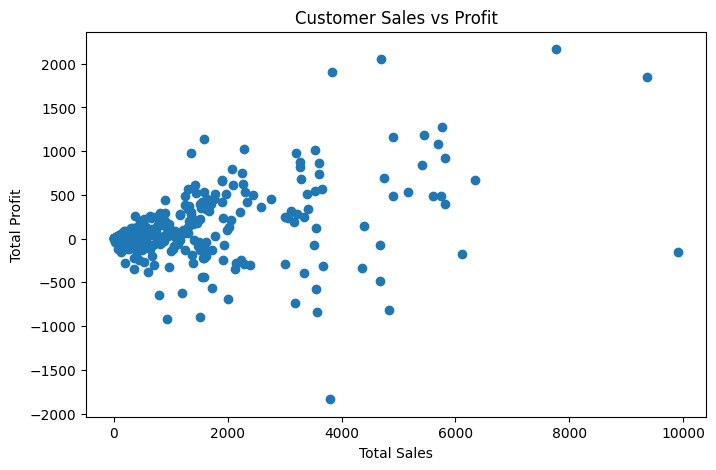

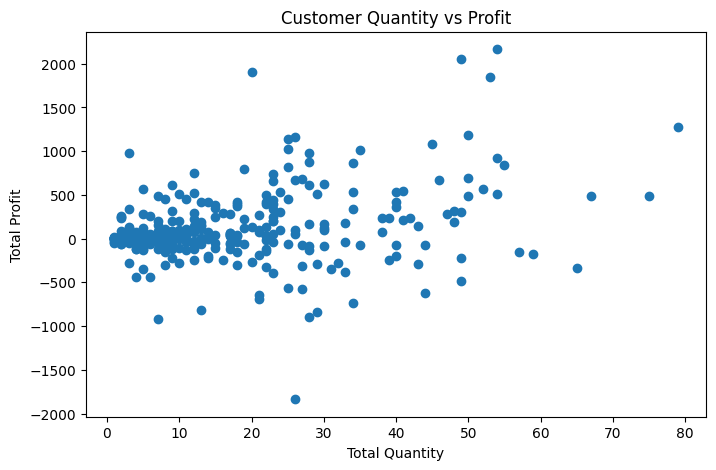

Category-level Relationship Patterns:
      Category  total_sales  total_profit  total_quantity  profit_margin
1  Electronics       166267         13162            1154           7.92
0     Clothing       144323         13325            3516           9.23
2    Furniture       127181         10476             945           8.24


In [ ]:
# 10. Relationship and pattern analysis
# What relationships between quantity, sales, profit, customer activity, and product segments can provide additional evidence for profitability improvement opportunities?

# DEFINING RELATIONSHIP

relationship_data = customer_analysis[
    [
        "total_sales",
        "total_profit",
        "total_quantity",
        "total_orders"
    ]
]

correlation_matrix = relationship_data.corr()

print(correlation_matrix.round(2))

# SALES VS PROFIT

plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analysis["total_sales"],
    customer_analysis["total_profit"]
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.title("Customer Sales vs Profit")

plt.show()

# QUANTITY VS PROFIT

plt.figure(figsize=(8, 5))

plt.scatter(
    customer_analysis["total_quantity"],
    customer_analysis["total_profit"]
)

plt.xlabel("Total Quantity")
plt.ylabel("Total Profit")
plt.title("Customer Quantity vs Profit")

plt.show()

# PRODUCT SEGMENT PATTERNS

segment_analysis = (
    details.groupby("Category")
           .agg(
               total_sales=("Amount", "sum"),
               total_profit=("Profit", "sum"),
               total_quantity=("Quantity", "sum")
           )
           .reset_index()
)

segment_analysis["profit_margin"] = (
    segment_analysis["total_profit"] /
    segment_analysis["total_sales"] * 100
)

print("Category-level Relationship Patterns:")

print(
    segment_analysis
    .sort_values("total_sales", ascending=False)
    .round(2)
)